# Combining images

### Lets now move onto combining processed science images 

### How does Guassian random noise change when we combine images?

In [10]:
# To use astropy we need to import libraries 


import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.time import Time
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from scipy.ndimage import shift

import os
import gc        

# Read in science images 

In [11]:
images = ccdproc.ImageFileCollection('./',glob_include = 'procNGC_3293_V*fits')
for filename in images.files_filtered():
    print(filename)

# Load all of the images in the list 

scim=[]
for filename in images.files_filtered():
    scim.append(CCDData.read(filename, unit = "adu"))


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


procNGC_3293_V_00003277.fits
procNGC_3293_V_00003280.fits
procNGC_3293_V_00003284.fits
procNGC_3293_V_00003388.fits
procNGC_3293_V_00003392.fits
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


# Combine science images 

In [12]:
scimav_proc = ccdproc.combine(scim, method='average', sigma_clip=False)

scimme_proc = ccdproc.combine(scim, method='median', sigma_clip=False)



# Display science images 

1159.9260816957258
1004.6853676626004 1714.712527863078


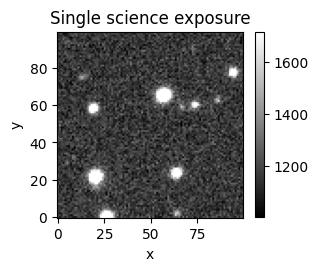

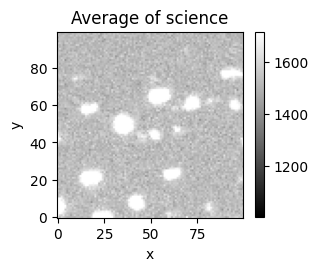

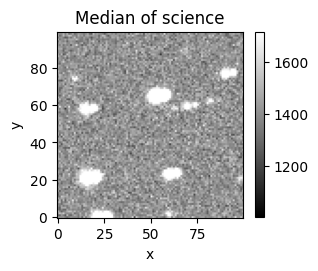

In [13]:

idx=0  # Index
med=np.median(scim[idx].data)
print(med)
p1=np.percentile(scim[idx].data, 1)
p99=np.percentile(scim[idx].data, 99)
print(p1,p99)

for jdx in [0, 1, 2]:
    plt.rcParams['figure.figsize'] = [3, 3]

    if jdx==0:
        #skydata=scim[idx]
        skydata=scim[idx].data[800:900,600:700]
        plt.title('Single science exposure')
    if jdx==1:
        #skydata=sciav_proc
        skydata=scimav_proc.data[800:900,600:700]
        plt.title('Average of science')
    if jdx==2:
        #skydata=cime_proc
        skydata=scimme_proc.data[800:900,600:700]
        plt.title('Median of science')
    
    plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
    ax = plt.gca()
    ax.invert_yaxis()
    plt.colorbar(shrink=0.8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# Comments 

### Stars - trailed

### Counts

### Background - background counts have increased

### Good? - no it is not. Trailed images

### Lets look at the images with ds9

###

###


# Background subtraction

### Lets get all the images to have the same background value of zero

### This will also mean counts are counts above/below sky

In [14]:
for im in scim:
    med=np.median(im.data)
    print('Median values:', med)
    im.data = im.data - med

print('Median of first image after subtraction: ', np.median(scim[0].data))

Median values: 1159.9260816957258
Median values: 1403.1270585321718
Median values: 1130.674325813139
Median values: 1950.6382871982319
Median values: 1967.3531000055473
Median of first image after subtraction:  0.0


# Shift images

### Shift the images so they have a common frame

### Identify a star and measure its position 

### Determine offsets required to shift images to align with a reference image

###

###

In [15]:
# List of approximate x-y coordinates 
starxy=[]

# 3277
starxy.append([1002, 786])
# 3280
starxy.append([998, 786])
# 3284
starxy.append([998, 785])
# 3280
starxy.append([981, 770])
# 3280
starxy.append([981, 770])

print(starxy)

[[1002, 786], [998, 786], [998, 785], [981, 770], [981, 770]]


# Centroid 

### We can define accurate positions using a centroid 

### A centroid if a flux weighted position for a object 

\begin{equation}
\bar{x} = \frac{\sum f_i x_i} {\sum f_i}
\end{equation}

\begin{equation}
\bar{y} = \frac{\sum f_i y_i} {\sum f_i}
\end{equation}

where $x_i$ and $y_i$ are the coordinates of the i-th pixel and $f_i$ is the counts (above background) in that pixel.

### An alternative approach is a 2D Gaussian fit to the starlight 

### Astropy has both options

### Lets extract a region around the star, determine the centroid and refine the position

###

###

In [16]:
# Importing the centroid functions 
from photutils.centroids import (centroid_1dg, centroid_2dg, centroid_com, centroid_quadratic)

# List of refined star coordinates 
newstarxy=[]

# This steps through the image list and generates a corresponding index (0, 1, 2...)
for idx, im in enumerate(scim):
    
    hbs=10 # Half box size 
    xc=int(starxy[idx][0]) # Integer of approximate x
    yc=int(starxy[idx][1]) # Integer of approximate y 
    starregion=im.data[yc-hbs:yc+hbs,xc-hbs:xc+hbs] # Data in region around star 

    # Centroid
    x1, y1 = centroid_com(starregion) 
    newstarxy.append([xc-hbs+x1, yc-hbs+y1])

    # Print key numbers to the screen 
    print(idx)
    print('Coords in subregion: ', x1, y1)
    print('Coords in entire image: ', newstarxy[-1])
    print('\n')

0
Coords in subregion:  8.211206916698405 10.22166563843123
Coords in entire image:  [np.float64(1000.2112069166984), np.float64(786.2216656384312)]


1
Coords in subregion:  8.135259493701 9.660830139933879
Coords in entire image:  [np.float64(996.135259493701), np.float64(785.6608301399339)]


2
Coords in subregion:  8.414013742904848 10.181195334670655
Coords in entire image:  [np.float64(996.4140137429049), np.float64(785.1811953346706)]


3
Coords in subregion:  7.759458450730577 10.438009460346072
Coords in entire image:  [np.float64(978.7594584507306), np.float64(770.438009460346)]


4
Coords in subregion:  7.876762140873714 10.045103711849453
Coords in entire image:  [np.float64(978.8767621408737), np.float64(770.0451037118495)]




# Determine shifts 

### We want to shift to the reference image 

### Can be easy to get things backwards 

###

In [17]:

# List of shifts
shiftsxy = []

# Step through the star coordinates 
for coord in newstarxy:

    # Subtract the star coords in the image *from* the reference position 
    shiftsxy.append([round(newstarxy[0][0]-coord[0]), round(newstarxy[0][1]-coord[1])])
    # Print shift to screen 
    print(shiftsxy[-1])
    



[0, 0]
[4, 1]
[4, 1]
[21, 16]
[21, 16]


### Check the shifts are in the correct direction

### I've rounded the shifts

### The reason is quite subtle 

### Will it matter for the image quality? 

In [18]:
# Step through the images 
shiftim=[]
for idx, im in enumerate(scim): 
    # Change shifts to yx - rows and columns 
    yxshifts=(shiftsxy[idx][1], shiftsxy[idx][0]) 
    # Apply shift to data
    temp = shift(im, yxshifts, order=0, mode='constant', cval=-1000) # If there is no data use a pixel value of -1000 
    # Convert shifted data to CCD data format and copy over header information
    tempim = CCDData(temp, unit="adu")
    tempim.header = im.header
    
    shiftim.append(tempim)
    # print(idx)
    #print(tempim)

0.0
-155.24071403312536 554.7864461673523
[[ -74.69640184   27.17216191  109.5794235  ...  -19.54770547
    11.85712097   13.76192475]
 [  83.08913464 -118.75572333 -154.55773943 ...  -96.06522424
    -2.31211165  -90.43836629]
 [  15.937718    -63.83929423  -20.47277934 ...  -56.79880911
   -55.19793879  -24.23646087]
 ...
 [  19.34795384   13.30888462   35.22253265 ...   74.74759637
    73.01244691 -176.97987315]
 [ 113.66240357  -49.02216681  119.20499579 ...  -90.79386966
   234.62277165  -70.07311464]
 [  24.23240718    2.64872752    8.99301679 ...  -61.16423386
  -109.1097657   -71.200318  ]] adu


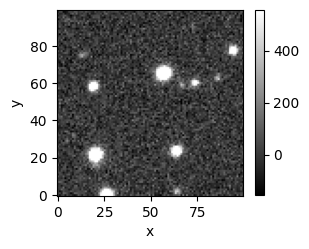

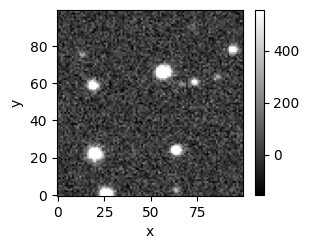

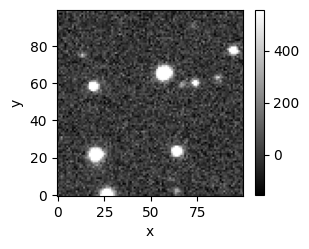

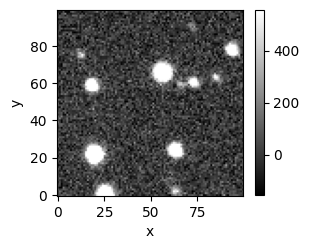

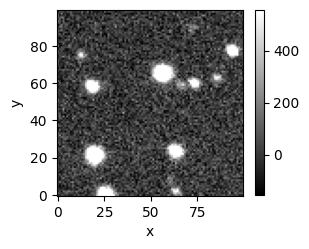

In [19]:
# Lets take a look

idx=0  # Index
med=np.median(scim[idx].data)
print(med)
p1=np.percentile(scim[idx].data, 1)
p99=np.percentile(scim[idx].data, 99)
print(p1,p99)
print(shiftim[0])

for im in shiftim:
    skydata=im.data[800:900,600:700]
    plt.rcParams['figure.figsize'] = [3, 3]
    plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
    ax = plt.gca()
    ax.invert_yaxis()
    plt.colorbar(shrink=0.8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# Writing images 

### Everything we have done so far is to data in the notebook 

### We have not modified the original images stored on the computer

### We will write out the shifted images, but to new file names 

### 

In [20]:
print('Original filenames')
for filename in images.files_filtered():
    print(filename)

print('New filenames')
newfilenames=[]
for filename in images.files_filtered():
    newfilenames.append('s'+filename)
    print(newfilenames[-1])

Original filenames
procNGC_3293_V_00003277.fits
procNGC_3293_V_00003280.fits
procNGC_3293_V_00003284.fits
procNGC_3293_V_00003388.fits
procNGC_3293_V_00003392.fits
New filenames
sprocNGC_3293_V_00003277.fits
sprocNGC_3293_V_00003280.fits
sprocNGC_3293_V_00003284.fits
sprocNGC_3293_V_00003388.fits
sprocNGC_3293_V_00003392.fits


In [21]:
for idx, im in enumerate(shiftim):
    im.header['MJD-OBS'] = float(im.header['MJD-OBS'])  # Fix header keyword issue
    im.write(newfilenames[idx], overwrite=True)